# 4. Custom subsystems

The built-in chain is a convenience. The generic API takes any subsystem you can
write as a continuous-time state equation `f(x, u, p, t) -> dx/dt` and a measurement
equation `h(x, u, p, t) -> y`. Here two single-degree-of-freedom oscillators, one
with a cubic (Duffing) spring, are coupled by a linear spring-damper. Subsystem
`A` estimates its unknown linear stiffness with an EKF, subsystem `B` tracks its
states with a UKF, and the interface force is exchanged by Gauss-Seidel message
passing.

In [1]:
import numpy as np

import pci

## The physics

`x` is the local state vector, `u` the vector of input ports (external load plus
the incoming interface message, summed by the library), `p` a plain dictionary of
parameters. Unknown parameters appear in `p` too, holding their running estimate,
so one function serves the forward model and the inverse problem.

In [2]:
def duffing(x, u, p, t):
    """x = [q, v]; p holds m, k, k3, c; u[0] is the total force on the mass."""
    q, v = x
    return np.array([v, (u[0] - p["k"] * q - p["k3"] * q**3 - p["c"] * v) / p["m"]])


def linear_sdof(x, u, p, t):
    q, v = x
    return np.array([v, (u[0] - p["k"] * q - p["c"] * v) / p["m"]])


def measure_accel(x, u, p, t):
    return duffing(x, u, p, t)[1:]  # accelerometer on A


def measure_disp(x, u, p, t):
    return x[:1]                     # displacement sensor on B

## Subsystems, interface, system

`Subsystem` bundles the physics with its estimator settings: filter type, initial
state `x0`, prior `P0`, process noise `Q`, measurement noise `R` and the names of the
data columns it consumes (`measured`). `spring_damper` returns the pair of directed
interfaces (one per direction) for a linear spring-damper between two subsystems.

In [3]:
A = pci.Subsystem("A", states=["q", "v"], inputs=["f"], dynamics=duffing, measurement=measure_accel,
                  parameters={"m": 1.0, "k3": 50.0, "c": 0.3},
                  unknowns={"k": pci.Unknown(initial=5.0, std=5.0)},
                  filter="ekf", x0={"q": 0.3}, P0=1e-4, Q=1e-10, R=1e-4, measured=["a_A"])
B = pci.Subsystem("B", states=["q", "v"], inputs=["f"], dynamics=linear_sdof, measurement=measure_disp,
                  parameters={"m": 2.0, "k": 20.0, "c": 0.4},
                  filter="ukf", P0=1e-4, Q=1e-10, R=1e-6, measured=["q_B"])
system = pci.System([A, B],
                    pci.spring_damper("A", ["q", "v"], "f", "B", ["q", "v"], "f", k=6.0, c=0.2, name="F_AB"),
                    schedule="gauss_seidel")
print(system.describe())

System 'system': 2 subsystems, 2 directed interfaces, schedule=GaussSeidel(iterations=1), messages='mean'
  - A: states=['q', 'v'], unknowns=['k'], inputs=['f'], measured=['a_A'], filter=ekf, integrator=heun
  - B: states=['q', 'v'], unknowns=[], inputs=['f'], measured=['q_B'], filter=ukf, integrator=heun
  - F_AB: B['q', 'v'] -> A.f (sign -1)
  - F_AB: A['q', 'v'] -> B.f (sign +1)


## Ground truth from a monolithic model

For a custom system you supply the data. Here we integrate the coupled two-mass
model with the true stiffness `k = 12` and read a noisy accelerometer on `A` and a
noisy displacement sensor on `B`.

In [4]:
dt, T = 1e-3, 20.0
N = int(T / dt)
t = dt * np.arange(N + 1)
p_true = {"m": 1.0, "k": 12.0, "k3": 50.0, "c": 0.3}
p_B = {"m": 2.0, "k": 20.0, "c": 0.4}
force = pci.HarmonicLoad(amplitude=2.0, frequency=0.7).sample(t[:-1])


def rhs(z, k):
    Fb = 6.0 * (z[0] - z[2]) + 0.2 * (z[1] - z[3])
    dA = duffing(z[:2], [force[k] - Fb], p_true, 0.0)
    dB = linear_sdof(z[2:], [Fb], p_B, 0.0)
    return np.concatenate([dA, dB])


Z = np.zeros((N + 1, 4)); Z[0] = [0.3, 0.0, 0.0, 0.0]
acc_A = np.zeros(N + 1)
for k in range(N):
    Z[k + 1] = pci.heun(lambda z, tt: rhs(z, k), Z[k], t[k], dt)
    acc_A[k + 1] = rhs(Z[k + 1], k)[1]
rng = np.random.default_rng(0)
data = {"a_A": acc_A + rng.normal(0, 1e-2, N + 1), "q_B": Z[:, 2] + rng.normal(0, 1e-3, N + 1)}

## Estimate

Loads are addressed by `Subsystem.port`. The truth is optional; it only feeds the
error metrics and the reference lines in the plots.

In [5]:
results = system.estimate(data, loads={"A.f": force}, dt=dt, n_steps=N,
                          truth={"A.q": Z[:, 0], "B.q": Z[:, 2], "k": 12.0})
print(results.summary(start=5.0))

mode=estimate  schedule=GaussSeidel(iterations=1)  steps=20000  runtime=2.95s
[A]
           q: final=-0.188998  std= 7.43e-05  rmse= 0.0004032
           v: final= 1.24122  std= 0.000374
           k: final= 11.9976  std= 0.00155  true= 12  rmse= 0.002894
[B]
           q: final= 0.0534367  std= 0.000101  rmse= 9.671e-05
           v: final=-0.546731  std= 0.000355
[messages] F_AB


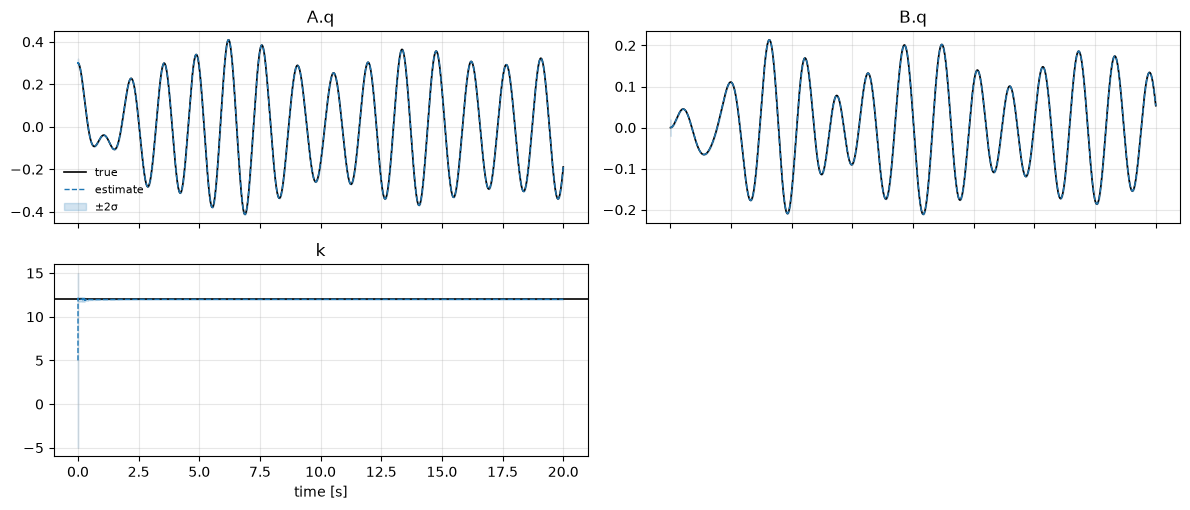

In [6]:
results.plot_states(["A.q", "B.q", "k"]);

## The YAML twin: equations as strings

With `sympy` installed, `model: custom` accepts the same subsystems as equation
strings (`04_custom_subsystems.yaml`). The ground truth is then the same coupled
model simulated with the true parameter values given under `truth.parameters`, so
no monolithic model has to be written.

In [7]:
print(open("04_custom_subsystems.yaml").read())

# YAML twin of 04_custom_subsystems.py: user-written equations (needs sympy).
# Subsystem A: Duffing oscillator with unknown linear stiffness k (EKF).
# Subsystem B: linear oscillator, states only (UKF). Coupled by a spring-damper, Gauss-Seidel messages.
model: custom
subsystems:
  A:
    states: [q, v]
    inputs: [f]                              # total force on the mass (external load + interface message)
    parameters: {m: 1.0, k3: 50.0, c: 0.3}
    unknowns: {k: {initial: 5.0, std: 5.0}}
    equations:                               # d/dt of each state
      q: v
      v: (f - k*q - k3*q**3 - c*v) / m
    measurements:
      a_A: (f - k*q - k3*q**3 - c*v) / m     # accelerometer on A
    noise_std: {a_A: 1.0e-2}
    filter: ekf
    integrator: heun
    x0: {q: 0.3}
    P0: 1.0e-4
    Q: 1.0e-10
  B:
    states: [q, v]
    inputs: [f]
    parameters: {m: 2.0, k: 20.0, c: 0.4}
    equations:
      q: v
      v: (f - k*q - c*v) / m
    measurements:
      q_B: q                     

In [8]:
yaml_results = pci.solve("04_custom_subsystems.yaml")
print(f"YAML twin: k final = {yaml_results.final('k'):.3f} (true 12.0)")

YAML twin: k final = 11.995 (true 12.0)
